# TorchPenny Doc004: QML Classifier

In this example, we will classify Two Moons data using `ZfeatureMap`, `RealAmplitude`, and a PyTorch linear layer.

In [1]:
import sys
from pathlib import Path

project_root = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "torchpenny" / "module.py").is_file()
)
sys.path.insert(0, str(project_root))


In [2]:
import torch
import pennylane as qml
from torch import nn
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset
from matplotlib import pyplot as plt

from torchpenny.module import QLayer
from torchpenny.lib.features import ZfeatureMap
from torchpenny.lib.ansatz import RealAmplitude

seed = 7
dtype = torch.float64
torch.manual_seed(seed)


## Two Moons dataset

Two Moons consists of two interleaving half-circles, with two coordinates and a binary label per sample.
We generate 400 noisy points using PyTorch, following the geometry of [make_moons](https://scikit-learn.org/stable/modules/generated/sklearn.datasets.make_moons.html).

In [3]:
n_per_class = 200
noise = 0.15
data_generator = torch.Generator().manual_seed(seed)

theta = torch.linspace(0, torch.pi, n_per_class, dtype=dtype)
moon0 = torch.stack([torch.cos(theta), torch.sin(theta)], dim=1)
moon1 = torch.stack([1 - torch.cos(theta), 0.5 - torch.sin(theta)], dim=1)
X = torch.cat([moon0, moon1])
X = X + noise * torch.randn(X.shape, generator=data_generator, dtype=dtype)
y = torch.cat([torch.zeros(n_per_class), torch.ones(n_per_class)]).to(dtype).unsqueeze(1)

print("Input shape:", X.shape)
print("Label shape:", y.shape)


Input shape: torch.Size([400, 2])
Label shape: torch.Size([400, 1])


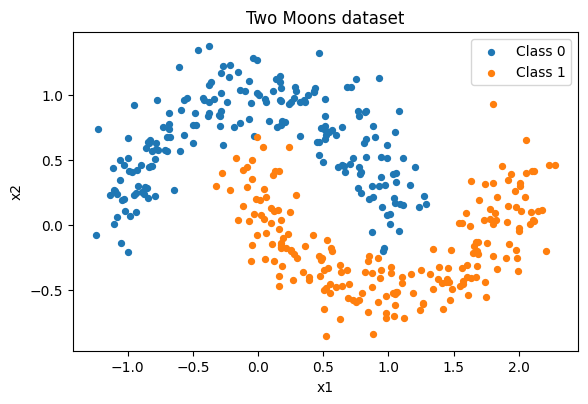

In [4]:
fig, ax = plt.subplots(figsize=(6, 4))
for label, color in [(0, "tab:blue"), (1, "tab:orange")]:
    points = X[y[:, 0] == label]
    ax.scatter(points[:, 0], points[:, 1], s=18, color=color, label=f"Class {label}")
ax.set(title="Two Moons dataset", xlabel="x1", ylabel="x2")
ax.set_aspect("equal", adjustable="box")
ax.legend()
fig.tight_layout()
plt.show()


## Prepare the data

We use 224 training, 56 validation, and 120 test samples.
Normalize all inputs using the training mean and standard deviation. Validation loss selects the model checkpoint.

In [5]:
development_indices, test_indices = [], []
for label in (0, 1):
    indices = torch.where(y[:, 0] == label)[0]
    indices = indices[torch.randperm(len(indices), generator=data_generator)]
    n_development = int(0.7 * len(indices))
    development_indices.append(indices[:n_development])
    test_indices.append(indices[n_development:])

# Split the development data without changing the previous test membership.
train_indices, validation_indices = [], []
for indices in development_indices:
    indices = indices[torch.randperm(len(indices), generator=data_generator)]
    n_train = int(0.8 * len(indices))
    train_indices.append(indices[:n_train])
    validation_indices.append(indices[n_train:])

train_indices = torch.cat(train_indices)
validation_indices = torch.cat(validation_indices)
test_indices = torch.cat(test_indices)
X_train_raw, y_train = X[train_indices], y[train_indices]
X_validation_raw, y_validation = X[validation_indices], y[validation_indices]
X_test_raw, y_test = X[test_indices], y[test_indices]

train_mean = X_train_raw.mean(dim=0)
train_std = X_train_raw.std(dim=0).clamp_min(1e-8)
X_train = (X_train_raw - train_mean) / train_std
X_validation = (X_validation_raw - train_mean) / train_std
X_test = (X_test_raw - train_mean) / train_std

train_loader = DataLoader(
    TensorDataset(X_train, y_train),
    batch_size=32,
    shuffle=True,
    generator=torch.Generator().manual_seed(seed),
)
print(f"Training: {len(X_train)}, validation: {len(X_validation)}, test: {len(X_test)}")


Training: 224, validation: 56, test: 120


## QLayer with QSubLayers

We repeat `ZfeatureMap(x) -> RealAmplitude` three times, then measure each qubit's Z expectation.
This repeated input encoding is called [data re-uploading](https://quantum-journal.org/papers/q-2020-02-06-226/).

`nn.ModuleList` stores independent ansatz parameters. `blocks` controls input repetition; `reps` controls the depth inside each ansatz.

In [6]:
class QuantumLayer(QLayer):
    def __init__(self, wires=2, blocks=3, reps=1):
        if type(blocks) is not int or blocks < 1:
            raise ValueError("`blocks` must be a positive integer.")
        super(QuantumLayer, self).__init__(
            wires=wires,
            q_device="default.qubit",
            qnode_kwargs={"diff_method": "backprop"},
        )
        self.feature_map = ZfeatureMap(self.wires, param_received=True)
        self.ansatz_layers = nn.ModuleList([
            RealAmplitude(
                self.wires,
                entanglement_structure="linear",
                reps=reps,
            )
            for _ in range(blocks)
        ])

    def inner_gates(self, x):
        for ansatz in self.ansatz_layers:
            self.feature_map(x, wires=range(self.wires))
            ansatz(wires=range(self.wires))

    def measurement(self):
        return [qml.expval(qml.PauliZ(i)) for i in range(self.wires)]


## Torch integration

The model adds a fixed `pi / 2` offset before encoding to break the circuit's input-sign symmetry.
A final `nn.Linear(2, 1)` converts the two quantum outputs into one classification logit.
We use `float64` for both quantum and classical layers.

In [7]:
class MoonClassifier(nn.Module):
    def __init__(self, blocks=3, reps=1):
        super(MoonClassifier, self).__init__()
        self.quantum = QuantumLayer(wires=2, blocks=blocks, reps=reps)
        self.classifier = nn.Linear(self.quantum.wires, 1)

    def forward(self, x):
        angles = x + torch.pi / 2
        features = self.quantum(angles)
        return self.classifier(features)


torch.manual_seed(seed)
model = MoonClassifier(blocks=3, reps=1).to(dtype=dtype)
model


MoonClassifier(
  (quantum): QuantumLayer[Qnode, wires=2](
    (feature_map): ZfeatureMap[2]()
    (ansatz_layers): ModuleList(
      (0-2): 3 x RealAmplitude()
    )
  )
  (classifier): Linear(in_features=2, out_features=1, bias=True)
)

In [8]:
print("External feature shapes:", model.quantum.input_features)
for name, params in model.named_parameters():
    print(f"{name}: {tuple(params.shape)}")
print("Total trainable parameters:", sum(p.numel() for p in model.parameters()))

with torch.no_grad():
    example_angles = X_train[:4] + torch.pi / 2
    print("Quantum output shape:", model.quantum(example_angles).shape)
    print("Classifier output shape:", model(X_train[:4]).shape)


External feature shapes: {'feature_map': torch.Size([2])}
quantum.ansatz_layers.0.params: (2, 2, 1)
quantum.ansatz_layers.1.params: (2, 2, 1)
quantum.ansatz_layers.2.params: (2, 2, 1)
classifier.weight: (1, 2)
classifier.bias: (1,)
Total trainable parameters: 15
Quantum output shape: torch.Size([4, 2])
Classifier output shape: torch.Size([4, 1])


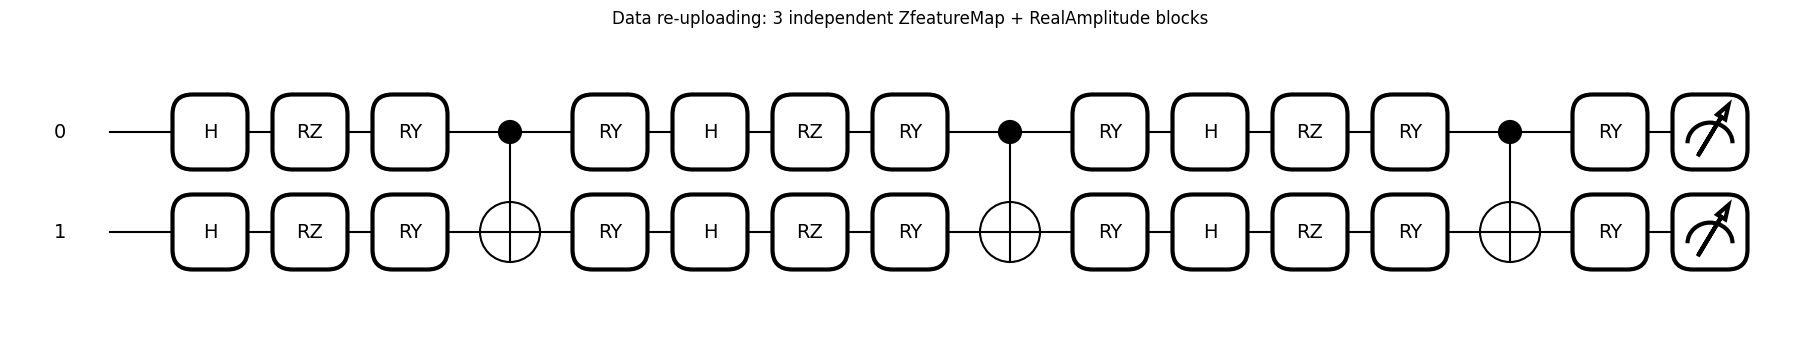

In [9]:
fig, ax = qml.draw_mpl(model.quantum.qnode)(example_angles[:1])
ax.set_title("Data re-uploading: 3 independent ZfeatureMap + RealAmplitude blocks")
plt.show()


## Training

Train all parameters with `Adam` and `BCEWithLogitsLoss`.
Pass raw logits to the loss without sigmoid, and keep labels in shape `(B, 1)`.
Restore the checkpoint with the lowest validation loss.

In [10]:
# Each repeated ansatz owns separate weights and receives gradients.
model.zero_grad()
probe_x = X_train[:32].clone().requires_grad_(True)
probe_loss = nn.BCEWithLogitsLoss()(model(probe_x), y_train[:32])
probe_loss.backward()

assert len({layer.params.data_ptr() for layer in model.quantum.ansatz_layers}) == len(model.quantum.ansatz_layers)
for i, layer in enumerate(model.quantum.ansatz_layers):
    assert layer.params.grad is not None and torch.isfinite(layer.params.grad).all()
    assert layer.params.grad.norm() > 0
    print(f"Block {i+1} gradient norm: {layer.params.grad.norm().item():.4f}")
assert probe_x.grad is not None and torch.isfinite(probe_x.grad).all()
model.zero_grad()


Block 1 gradient norm: 0.0781
Block 2 gradient norm: 0.1409
Block 3 gradient norm: 0.1470


In [11]:
loss_func = nn.BCEWithLogitsLoss()
optim = Adam(model.parameters(), lr=0.03)
total_epochs = 100
history = {"loss": [], "accuracy": [], "validation_loss": [], "validation_accuracy": []}
best_validation_loss = float("inf")
best_state = None
best_epoch = 0

for epoch in range(total_epochs):
    model.train()
    for batch_x, batch_y in train_loader:
        optim.zero_grad()
        logits = model(batch_x)
        loss = loss_func(logits, batch_y)
        loss.backward()
        optim.step()

    model.eval()
    with torch.no_grad():
        train_logits = model(X_train)
        train_loss = loss_func(train_logits, y_train).item()
        train_accuracy = ((train_logits >= 0) == y_train.bool()).to(dtype).mean().item()
        validation_logits = model(X_validation)
        validation_loss = loss_func(validation_logits, y_validation).item()
        validation_accuracy = ((validation_logits >= 0) == y_validation.bool()).to(dtype).mean().item()

    history["loss"].append(train_loss)
    history["accuracy"].append(train_accuracy)
    history["validation_loss"].append(validation_loss)
    history["validation_accuracy"].append(validation_accuracy)
    if validation_loss < best_validation_loss:
        best_validation_loss = validation_loss
        best_epoch = epoch + 1
        best_state = {name: value.detach().clone() for name, value in model.state_dict().items()}
    if (epoch + 1) % 20 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:3}/{total_epochs} | Train loss: {train_loss:.4f}, accuracy: {train_accuracy:.1%}"
              f" | Validation loss: {validation_loss:.4f}, accuracy: {validation_accuracy:.1%}")

model.load_state_dict(best_state)
print(f"Restored epoch {best_epoch}: validation loss = {best_validation_loss:.4f}")


Epoch   1/100 | Train loss: 0.6547, accuracy: 68.8% | Validation loss: 0.6349, accuracy: 83.9%
Epoch  20/100 | Train loss: 0.1420, accuracy: 96.4% | Validation loss: 0.1225, accuracy: 96.4%
Epoch  40/100 | Train loss: 0.0815, accuracy: 98.2% | Validation loss: 0.0624, accuracy: 100.0%
Epoch  60/100 | Train loss: 0.0569, accuracy: 98.7% | Validation loss: 0.0429, accuracy: 100.0%
Epoch  80/100 | Train loss: 0.0431, accuracy: 99.1% | Validation loss: 0.0278, accuracy: 100.0%
Epoch 100/100 | Train loss: 0.0356, accuracy: 99.1% | Validation loss: 0.0217, accuracy: 100.0%
Restored epoch 94: validation loss = 0.0214


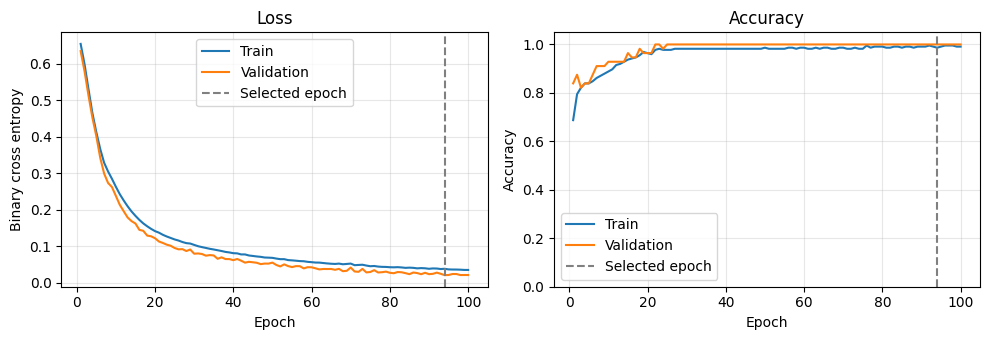

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))
epochs = range(1, total_epochs + 1)
axes[0].plot(epochs, history["loss"], label="Train")
axes[0].plot(epochs, history["validation_loss"], label="Validation")
axes[0].set(title="Loss", xlabel="Epoch", ylabel="Binary cross entropy")
axes[1].plot(epochs, history["accuracy"], label="Train")
axes[1].plot(epochs, history["validation_accuracy"], label="Validation")
axes[1].set(title="Accuracy", xlabel="Epoch", ylabel="Accuracy", ylim=(0, 1.05))
for ax in axes:
    ax.axvline(best_epoch, color="gray", linestyle="--", label="Selected epoch")
    ax.grid(alpha=0.3)
    ax.legend()
fig.tight_layout()
plt.show()


## Test results

Apply sigmoid to obtain class-1 probabilities and classify at a threshold of 0.5.

In [13]:
model.eval()
with torch.no_grad():
    test_logits = model(X_test)
    test_probabilities = torch.sigmoid(test_logits)
    test_predictions = (test_probabilities >= 0.5).to(dtype)
    test_loss = loss_func(test_logits, y_test).item()
    test_accuracy = (test_predictions == y_test).to(dtype).mean().item()

print(f"Test loss: {test_loss:.4f}")
print(f"Test accuracy: {test_accuracy:.1%} ({int((test_predictions == y_test).sum())}/{len(y_test)})")


Test loss: 0.0375
Test accuracy: 99.2% (119/120)


## Decision boundary

The background shows class-1 probability. The black line is the 0.5 boundary, and crosses mark misclassified test points.

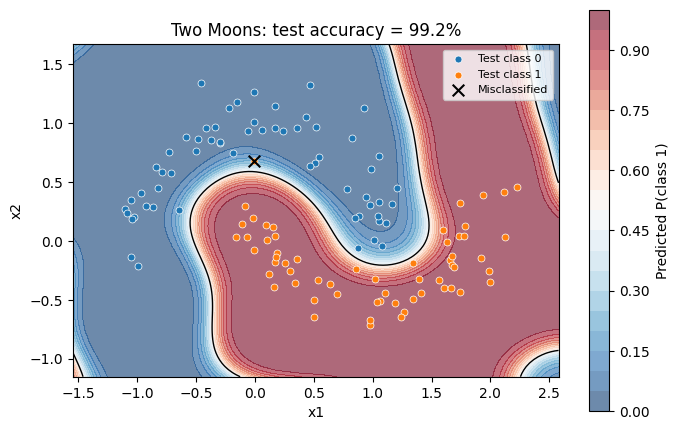

In [14]:
x1 = torch.linspace(X[:, 0].min() - 0.3, X[:, 0].max() + 0.3, 120, dtype=dtype)
x2 = torch.linspace(X[:, 1].min() - 0.3, X[:, 1].max() + 0.3, 100, dtype=dtype)
grid_x1, grid_x2 = torch.meshgrid(x1, x2, indexing="xy")
grid_raw = torch.stack([grid_x1.reshape(-1), grid_x2.reshape(-1)], dim=1)
grid_scaled = (grid_raw - train_mean) / train_std

with torch.no_grad():
    # Keep simulator batches small even for a dense plotting grid.
    grid_probabilities = torch.cat([
        torch.sigmoid(model(batch)) for batch in grid_scaled.split(256)
    ]).reshape(grid_x1.shape)

fig, ax = plt.subplots(figsize=(7, 4.5))
background = ax.contourf(
    grid_x1.numpy(), grid_x2.numpy(), grid_probabilities.numpy(),
    levels=torch.linspace(0, 1, 21).numpy(), cmap="RdBu_r", alpha=0.6,
)
ax.contour(
    grid_x1.numpy(), grid_x2.numpy(), grid_probabilities.numpy(),
    levels=[0.5], colors="black", linewidths=1,
)
for label, color in [(0, "tab:blue"), (1, "tab:orange")]:
    points = X_test_raw[y_test[:, 0] == label]
    ax.scatter(points[:, 0], points[:, 1], s=25, color=color,
               edgecolors="white", linewidths=0.5, label=f"Test class {label}")
mistakes = X_test_raw[(test_predictions != y_test).squeeze(1)]
if len(mistakes):
    ax.scatter(mistakes[:, 0], mistakes[:, 1], marker="x", s=70,
               color="black", label="Misclassified")
fig.colorbar(background, ax=ax, label="Predicted P(class 1)")
ax.set(title=f"Two Moons: test accuracy = {test_accuracy:.1%}", xlabel="x1", ylabel="x2")
ax.set_aspect("equal", adjustable="box")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()
plt.show()


## Try different circuits

Change `blocks` or `reps`, then recreate the model and optimizer before training. This example demonstrates integration, not a quantum-advantage benchmark.